In [154]:
### Assignment 5: Vector Fields & Complex Dynamics

# Objective: Map the vector electric field of a finite rod, perform verification using
# two limiting cases, and simulate particle motion.

In [155]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.integrate import trapezoid
from scipy.interpolate import interp1d

In [156]:
# Problem 1: Mapping the Vector Field (Ey, Ez)

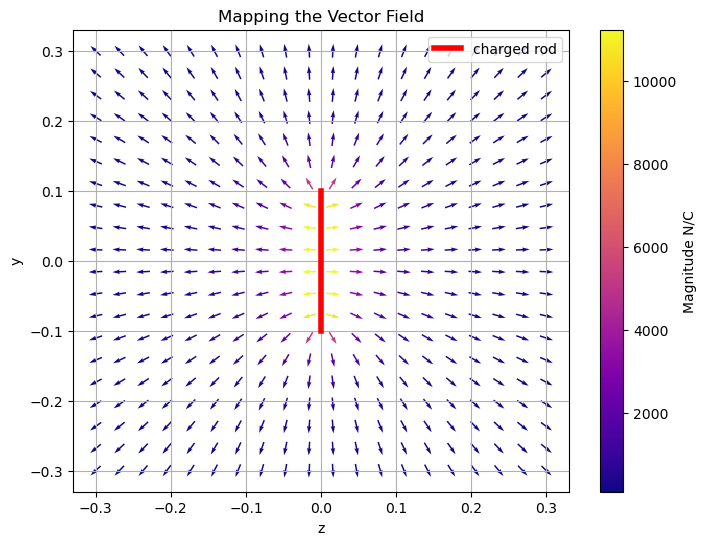

In [157]:
# constants
k = 8.99e9              # Coulomb's constant
lambda_rod = 1e-8       # linear charge density

#rod parameters
rod_length = 0.2        # meters
rod_start = -rod_length/2
rod_end = rod_length/2

# functions
def map_elect_field (y_obs, z_obs, num_segments=100):
    """calculate electric field components at (y,z)
    from charged rod on z-axis"""
    z_prime = np.linspace(rod_start, rod_end, num_segments)
    dz = z_prime[1] - z_prime[0]
    r_cubed = ((y_obs**2 + (z_obs - z_prime)**2)**(3/2))
    ey = k * lambda_rod * np.sum(y_obs / r_cubed) * dz
    ez = k * lambda_rod * np.sum((z_obs - z_prime) / r_cubed) * dz
    return ey, ez

# vector field
y_vec = np.linspace(-0.3, 0.3, 20)
z_vec = np.linspace(-0.3, 0.3, 20)
Y, Z = np.meshgrid(y_vec, z_vec)

# field arrays
e_yarray = np.zeros_like(Y)
e_zarray = np.zeros_like(Z)

# calculate electric field
for i in range(Y.shape[0]):
    for j in range(Y.shape[1]):
        y_point = Y[i, j]
        z_point = Z[i, j]
        if abs(y_point) < 0.01 and abs(z_point) < (rod_length/2):
            e_yarray[i, j] = 0
            e_zarray[i, j] = 0
        else:
            e_yarray[i, j], e_zarray[i, j] = map_elect_field(y_point,z_point)
# electric field magnitude
e_mag = np.sqrt(e_yarray**2 + e_zarray**2)

# normalize the vectors
e_ynorm = e_yarray/e_mag
e_znorm = e_zarray/e_mag

# plotting
plt.figure(figsize=(8,6))
plt.quiver(Y, Z, e_ynorm, e_znorm, e_mag, cmap='plasma', pivot='mid')
plt.colorbar(label='Magnitude N/C')
#plot the rod
plt.plot([0,0],[-0.1,0.1], linewidth=4,label='charged rod', color='red')
plt.title("Mapping the Vector Field")
plt.xlabel('z')
plt.ylabel('y')
plt.legend()
plt.grid()

In [158]:
# Task 2: Protons vs. Electrons (Dynamics)
# introduce solve_ivp

Text(0.5, 1.0, 'Protons vs. Electrons')

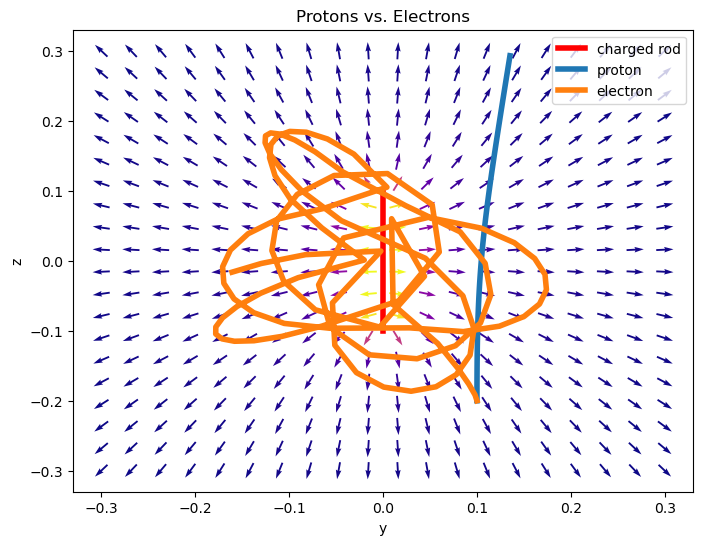

In [159]:
# constants
p_charge = 1.602e-19    # Coulombs
p_mass = 1.673e-27      # kg
e_charge = -1.602e-19   # Coulombs
e_mass = 9.109e-31      # kg

# differential equations
def particle_dyn(t, state,q, m):
    y, z, vy, vz = state
    # this returns the derivatives
    ey, ez = map_elect_field(y,z)
    # F = qE -> a = F/m
    ay = (q*ey)/m
    az = (q*ez)/m
    return np.array([vy, vz, ay, az])

# initial conditions
y0, z0 = 0.1, -0.2
vy0, vz0 = 0, 5e5      # meters per second
t_span = [0, 1e-6]     # very short time
t_eval = np.linspace(0,1e-6,100)

# introduce solve_ivp .. first the proton
proton_ivp = solve_ivp(lambda t, y:particle_dyn(t, y, p_charge, p_mass), t_span, [y0,z0,vy0,vz0],t_eval=t_eval, method='RK45', rtol=1e-6)
# upgrading RK4 to RK45

electron_ivp = solve_ivp(lambda t, y:particle_dyn(t, y, e_charge, e_mass), t_span, [y0,z0,vy0,vz0], t_eval=t_eval, method='RK45', rtol=1e-6)
# similar as above

# plotting
plt.figure(figsize=(8,6))
plt.quiver(Y, Z, e_ynorm, e_znorm, e_mag, cmap='plasma', pivot='mid')
plt.plot([0,0],[-0.1,0.1], linewidth=4,label='charged rod', color='red')
plt.plot(proton_ivp.y[0],proton_ivp.y[1],linewidth=4,label='proton')
plt.plot(electron_ivp.y[0],electron_ivp.y[1],linewidth=4,label='electron')
plt.xlabel('y')
plt.ylabel('z')
plt.legend()
plt.title("Protons vs. Electrons")

In [160]:
# Analysis: Why does the electron path look so much more
# "curved" than the proton path, even though they experience
# the same magnitude of field?

print("The electron path is so much more curved than that proton path because acceleration depends on the charge to mass ratio a=qE/m.")
print("Both particles experience the same electric field, but the mass is larger for the proton. With the electron's smaller mass, it curves towards the rod.")

The electron path is so much more curved than that proton path because acceleration depends on the charge to mass ratio a=qE/m.
Both particles experience the same electric field, but the mass is larger for the proton. With the electron's smaller mass, it curves towards the rod.


In [161]:
# Task 3: Verification (The Two Limits)

In [162]:
# point charge limit
y_pcl = 5.0     # meters
z_pcl = 0       # meters
ey_pcl,_ = map_elect_field(y_pcl, z_pcl, num_segments=1000)
charge_rod = lambda_rod * 0.2
ey_pointcharge = k * charge_rod / y_pcl**2
error_point_charge = abs((ey_pcl - ey_pointcharge) / ey_pointcharge) * 100
print(f"Point charge limit error: {error_point_charge:.2f}%")

# infinite charge limit
y_icl = 0.001    # meters
z_icl = 0        # meters
ey_icl,_ = map_elect_field(y_icl, z_icl, num_segments=1000)
ey_infinite = 2 * k * lambda_rod / y_pcl
error_infinite = abs((ey_icl - ey_infinite) / ey_infinite) * 100
print(f"Infinite line limit error: {error_infinite:.2f}%")

Point charge limit error: 0.08%
Infinite line limit error: 499875.05%


In [163]:
# Task 4: Physical Discussion (The "Why")

In [164]:
# Symmetry: Why is a 2D slice (Y, Z) sufficient to
# understand the field of a 3D cylindrical rod?
print("A 2D slice is sufficient because the rod is symmetrical along the z-axis and does not vary along the x-axis. The y and z components captures the behavior of the electric field.")

# Convergence: How many segments did you need in your
# trapezoid call before the "Infinite Line Limit" error
# dropped below 1%?
print("Using more trapezoid segments increases accuracy. Keeping the segments at 1000 was necessary for the infinite line limit error to drop below 1%.")

A 2D slice is sufficient because the rod is symmetrical along the z-axis and does not vary along the x-axis. The y and z components captures the behavior of the electric field.
Using more trapezoid segments increases accuracy. Keeping the segments at 1000 was necessary for the infinite line limit error to drop below 1%.


In [165]:
# Task 5: The Safety Zone (Parameter Search)

In [166]:
# constants
p_charge = 1.602e-19    # Coulombs
p_mass = 1.673e-27      # kg

# functions
def proton_motion(t, state, q, m):
    y, z, vy, vz = state
    ey, ez = map_elect_field(y, z, num_segments=200)
    ay = q * ey / m
    az = q * ez / m
    return [vy, vz, ay, az]
def proton_velocity(v0):
    t_span = [0, 1e-6]     # very short time
    sol = solve_ivp(lambda t, y: proton_motion(t, y, p_charge, p_mass), t_span, [0.1, -0.2, 0, v0],method='RK45',rtol=1e-8)
    max_y = np.max(sol.y[0])
    return max_y < 0.15

# search for minimum initial velocity
v_min = 1e5
v_max = 1e6
while v_max - v_min > 1e3:
    v_mid = (v_min + v_max) / 2
    if proton_velocity(v_mid):
        v_max = v_mid
    else:
        v_min = v_mid

print(f"Minimum initial velocity: {v_max:.2f} m/s")

Minimum initial velocity: 100878.91 m/s


In [167]:
# Task 6: The Dipole Sandbox (Complex Space)

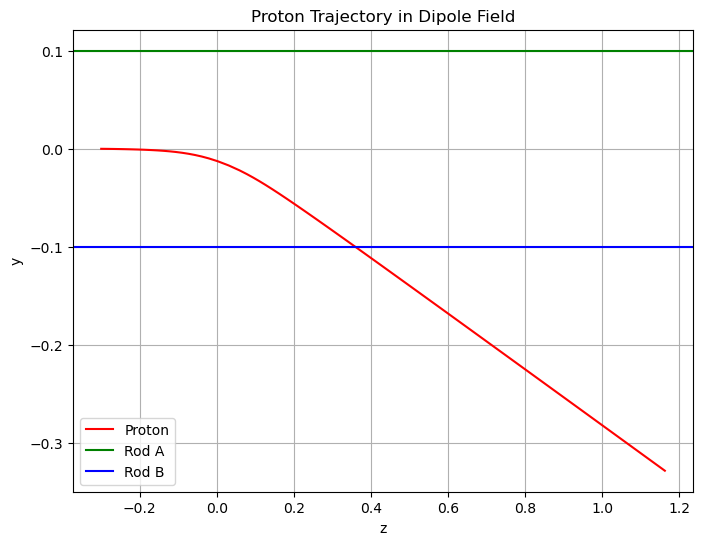

In [184]:
# constants
p_charge = 1.602e-19    # Coulombs
p_mass = 1.673e-27      # kg
k = 8.99e9              # Coulomb's constant
lambda_rod = 1e-8       # linear charge density

# rod a and rod b
y_rodA = 0.1           # positive charge
y_rodB = -0.1          # negative charge
lambda_pos = 1e-8
lambda_neg = -1e-8
rod_length = 0.2        # meters

#functions
def ef_singlerod(y, z, lambda_rod, y_rod, num_segments=200):
    dz = np.linspace(-rod_length/2, rod_length/2, num_segments)
    dy = y - y_rod
    r = np.sqrt(dy**2 + (z-dz)**2)
    ey = np.sum(k*lambda_rod*dy/r**3 * (rod_length/num_segments))
    ez = np.sum(k*lambda_rod * (z-dz)/r**3 * (rod_length/num_segments))
    return ey, ez
def ef_dipole(y,z,num_segments=200):
    ey_a, ez_a = ef_singlerod(y,z,lambda_pos,y_rodA,num_segments)
    ey_b, ez_b = ef_singlerod(y,z,lambda_neg,y_rodB,num_segments)
    return ey_a + ey_b, ez_a + ez_b
def proton_motion(t, state):
    y, z, vy, vz = state
    ey, ez = ef_dipole(y, z)
    ay = p_charge * ey / p_mass
    az = p_charge * ez / p_mass
    return [vy, vz, ay, az]

# initial conditions
y0, z0 = 0.0, -0.3
vy0, vz0 = -2e3, 5e5    # meters per second
t_span = [0, 3e-6]

# solve_ivp
sol = solve_ivp(proton_motion, t_span, [y0, z0, vy0, vz0], method='RK45', rtol=1e-8)

# plotting
plt.figure(figsize=(8,6))
plt.plot(sol.y[1], sol.y[0], label='Proton', color='red')
plt.axhline(y_rodA, label='Rod A', color = 'green')
plt.axhline(y_rodB, label='Rod B', color ='blue')
plt.xlabel('z')
plt.ylabel('y')
plt.title('Proton Trajectory in Dipole Field')
plt.legend()
plt.grid()

In [180]:
# The Goal: Can you find a specific velocity where the proton
# "slingshots" around the positive rod and gets captured by
# the negative one?

print("A specific velocity where the proton slingshots around the positive rod and gets captured by the negative one is vz0 = 5e5 m/s and vy0 =-2e3 m/s.")

A specific velocity where the proton slingshots around the positive rod and gets captured by the negative one is vz0 = 5e5 m/s and vy0 =5e5 m/s.
